In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def simulate_investment(initial_investment, fixed_rate, mean_return, std_dev, proportion_risky, years, simulations):
    proportion_fixed = 1 - proportion_risky
    results = []
    for _ in range(simulations):
        portfolio_value = initial_investment
        for _ in range(years):
            random_return = np.exp(np.random.normal(mean_return, std_dev)) - 1
            portfolio_return = (proportion_fixed * fixed_rate) + ((1 - proportion_fixed) * random_return)
            portfolio_value *= (1 + portfolio_return)
        results.append(portfolio_value)
    mean_end_value = np.mean(results)
    theoretical_return_single_period = proportion_fixed * fixed_rate + proportion_risky * (np.exp(mean_return + 0.5 * std_dev**2) - 1)
    theoretical_end_value   = (1 + theoretical_return_single_period) ** years * initial_investment
    return theoretical_return_single_period, theoretical_end_value, mean_end_value

In [4]:
def simulate_investment_test(initial_investment, fixed_rate, mean_return, std_dev, proportion_risky, years, x):
    proportion_fixed = 1 - proportion_risky
    portfolio_value = initial_investment
    for i in range(years):
        random_return = np.exp(x[i]) - 1
        portfolio_return = (proportion_fixed * fixed_rate) + ((1 - proportion_fixed) * random_return)
        portfolio_value *= (1 + portfolio_return)
    return portfolio_value

In [5]:
x = np.random.normal(0.04, 0.4, 24)
v=simulate_investment_test(1, 0.05, 0.04, 0.4, 0.5, 24, x)
print(v)

2.094473457996234


In [6]:
#save v to investment_output.txt
with open("investment_output.txt", "w") as f:
    f.write(str(v))
# Example usage


In [7]:
a=simulate_investment(1, 0.0025, 0.004, 0.05, 0.5, 24, 10000)
print(a) 

(0.00388190269943725, 1.0974456042155833, 1.098199322275022)


In [8]:
a_values = []
proportions = np.linspace(0, 1, 11)
for p in proportions:
    _, theor_value, mean_end_value = simulate_investment(1, 0.05, 0.05, 0.1, p, 10, 500)
    a_values.append([theor_value, mean_end_value])

In [9]:
print(a_values)

[[1.628894626777442, 1.6288946267774416], [1.639069756426215, 1.640720893246809], [1.649302054782459, 1.644744546043503], [1.6595918071800873, 1.6573908273422233], [1.6699393001983471, 1.6905970428143273], [1.6803448216664754, 1.6762428847044688], [1.6908086606683692, 1.6857977783112519], [1.70133110754727, 1.7200923557360335], [1.7119124539104638, 1.7379064642946551], [1.722552992633995, 1.7313142990359582], [1.7332530178673957, 1.726225735746544]]


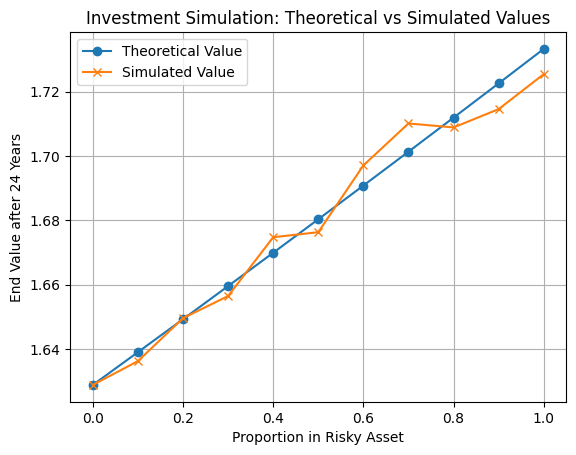

In [12]:
plot_proportions = proportions
theoretical_values = [v[0] for v in a_values]
simulated_values = [v[1] for v in a_values]
plt.plot(plot_proportions, theoretical_values, label='Theoretical Value', marker='o')
plt.plot(plot_proportions, simulated_values, label='Simulated Value', marker='x')
plt.xlabel('Proportion in Risky Asset')
plt.ylabel('End Value after 24 Years')
plt.title('Investment Simulation: Theoretical vs Simulated Values')
plt.legend()
plt.grid()
plt.show()
